# **Kenyan EV charging station location optimization using population** 

## **Business Understanding**

### **Overview** 

The transition to electric vehicles (EVs) in Kenya is steadily gaining momentum due to :


~ Rising fuel costs - https://www.africanews.com/2023/09/15/fuel-prices-hit-all-time-high-in-kenya/.

~ Environmental concerns - https://en.wikipedia.org/wiki/Environmental_issues_in_Kenya.

~ Government support for clean energy adoption - National EV Policy (government PDF) - https://www.transport.go.ke/sites/default/files/Emobility%20Policy%20Final.pdf.

However, the growth of EV usage is heavily dependent on the availability and accessibility of charging infrastructure. Poorly planned charging station placement can lead to underutilized assets, high operational costs, and limited EV adoption.

This project focuses on developing a data-driven optimization framework to determine the most strategic locations for EV charging stations across Kenya using population data as the primary demand indicator. 


By integrating:

~ Population density data

~ Geospatial analysis (latitude & longitude coordinates)

~ Demand forecasting models

~ Machine learning and clustering techniques

The system aims to rank and recommend optimal charging station locations.

Ultimately, this project provides policymakers, investors, utility providers, and urban planners with a practical decision-support tool to guide efficient EV infrastructure deployment across Kenya.

### **Business Problem and Stakeholders**

According to this source; [Kenya: EV numbers surge, more charging stations to be rolled out](https://www.esi-africa.com/news/kenya-ev-numbers-surge-more-charging-stations-to-be-rolled-out/),
 the increase in electric vehicles in Kenya has created pressure on charging infrastructure. Many areas lack sufficient charging stations, while others are underutilized. 
 
A Single Station Cuts Charging Time and Hints at What a Functioning National EV Network Might Finally Look Like. This is from, [The new charger lands in a city where riders are counting every minute they lose to slow stations that still sit too far apart](https://techtrendske.co.ke/2025/11/19/kenya-ev-fast-charging-network/)

The primary stakeholders for this problem are Government; Ministry of Transport and Ministry of Energy, EV charging investors, EV drivers and EV charging companies.The government uses the system for data-driven infrastructure planning, investors identify profitable charging locations, EV companies improve fleet operations and expansion decisions, and EV drivers gain easier access to reliable nearby charging stations.

### **Objectives**

1. Where should new EV charging stations be placed in each county in Kenya to ensure equitable population coverage?

2. How many charging stations are currently available per county, and how many additional stations are required to meet minimum population-based infrastructure needs?

3. How can charging infrastructure be spatially distributed within counties to maximize coverage and reduce clustering inefficiencies?

4. How can projected population growth be used to estimate the number of additional EV charging stations needed in the future?

### **Business Solution**

This project aims to develop a data-driven EV charging infrastructure optimization model for Kenya that integrates population distribution, county area size, existing station counts, and spatial coordinates to determine infrastructure gaps and recommend expansion strategies.  

Using population-based thresholds and applying spatial clustering techniques, number of new stations required per county are to be identified and the model should generate optimized geographic coordinates for their placement.  

Additionally, a machine learning model is to be trained to predict required charging stations based on demographic and spatial infrastructure features, enabling scalable and future-ready planning as population grows.  

The final outcome should be a strategic decision-support tool that guides policymakers, the kenyan government and energy stakeholders on where and how to expand Kenya’s EV charging network efficiently and equitably.

## **Data Understanding** 


The datasets utilized in this project are:
* `charging_station.csv`  [Hugging Face](https://huggingface.co/datasets/tarekmasryo/global-ev-infra-dataset),
This dataset shows the co-ordinates, charging station names, power class, country code and state province of different charging stations across the world.


* `kenya_ev_charging_stations_sample_new.csv` [Fundi wa EV](https://www.fundiwaev.co.ke/ev_database) This dataset expounds deeper into charging stations in Kenya.
The columns utilized in this dataset are County/City, Station name, Charger Type and Co-ordinates.

* `kenya-poulation-distribution-2019.csv` [Kaggle](https://www.kaggle.com/datasets/paulmaluki/kenyapopulationdistibution-2019-censuscsv) This dataset shows population density in different counties across Kenya.

* `ken_adminboundaries_tabulardata.xlsx` [OCHA services](https://data.humdata.org/dataset/cod-ab-ken) This dataset shows details on county boundaries across the country.
The Shape Area for each county was the core column utilized in this dataset.

* `county_coordinates.csv` This dataset contains county co-ordinate centroids.


In [97]:
# Import necessary libraries for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import folium

import re
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate, RepeatedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix,silhouette_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
from scipy.spatial.distance import cdist

import joblib



# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)



This section imports all necessary libraries for the project:

- **Data Manipulation**: `pandas`, `numpy` for handling datasets and numerical operations
- **Visualization**: `matplotlib`, `seaborn`, `folium` for creating plots and interactive maps
- **Machine Learning**: `scikit-learn` modules for clustering (KMeans), regression (RandomForest), and model evaluation
- **Utilities**: `warnings` to suppress unnecessary warning messages

The visualization style is set to 'whitegrid' for cleaner plots, and figure sizes are standardized for consistency.

## **1. Global Charging Stations Dataset**

**Source**: HuggingFace - global-ev-infra-dataset

This dataset contains information about EV charging stations worldwide, including:
- Station identifiers and names
- Geographic co-ordinates (latitude/longitude)
- Location details (city, state/province, country)
- Technical specifications (number of ports, power output, charging type)

We'll filter this dataset to extract Kenyan stations for our analysis.

In [98]:
# Load global charging stations dataset
global_stations_df= pd.read_csv('./Data/charging_station.csv')
# Display first few rows to understand structure
global_stations_df.head()

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
0,307660,Av. de Tarragona,Andorra,UNKNOWN,AD,42.505254,1.528861,10,300.0,DC_ULTRA_(>=150kW),True
1,301207,Parquing Costa Rodona,Encamp,UNKNOWN,AD,42.537213,1.727014,10,22.0,AC_HIGH_(22-49kW),False
2,301206,Hotel Naudi,Unknown City,UNKNOWN,AD,42.576811,1.666061,1,11.0,AC_L2_(7.5-21kW),False
3,301205,Hotel Piolets Soldeu Centre,Unknown City,UNKNOWN,AD,42.576466,1.667317,1,22.0,AC_HIGH_(22-49kW),False
4,301204,Hotel Serras,Unknown City,UNKNOWN,AD,42.579458,1.659215,3,11.0,AC_L2_(7.5-21kW),False


In [99]:
# Check data types and missing values
global_stations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242417 entries, 0 to 242416
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              242417 non-null  int64  
 1   name            242417 non-null  object 
 2   city            242417 non-null  object 
 3   state_province  242417 non-null  object 
 4   country_code    242417 non-null  object 
 5   latitude        242417 non-null  float64
 6   longitude       242417 non-null  float64
 7   ports           242417 non-null  int64  
 8   power_kw        237757 non-null  float64
 9   power_class     242417 non-null  object 
 10  is_fast_dc      242417 non-null  bool   
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 18.7+ MB


In [100]:
# Examine unique country codes to identify Kenyan entries
global_stations_df['country_code'].unique()

array(['AD', 'AE', 'AF', 'AL', 'AM', 'AR', 'AT', 'AU', 'AX', 'AZ', 'BA',
       'BB', 'BE', 'BG', 'BH', 'BR', 'BW', 'BY', 'CA', 'CH', 'CL', 'CN',
       'CO', 'CR', 'CY', 'CZ', 'DE', 'DK', 'DO', 'EC', 'EE', 'EG', 'ES',
       'ET', 'FI', 'FO', 'FR', 'GB', 'GE', 'GG', 'GH', 'GI', 'GR', 'GT',
       'HK', 'HR', 'HU', 'ID', 'IE', 'IL', 'IM', 'IN', 'IQ', 'IS', 'IT',
       'JE', 'JM', 'JO', 'JP', 'KE', 'KG', 'KH', 'KR', 'KZ', 'LI', 'LK',
       'LT', 'LU', 'LV', 'MA', 'MC', 'MD', 'ME', 'MK', 'MM', 'MO', 'MT',
       'MX', 'MY', 'NAM', 'NL', 'NO', 'NP', 'NZ', 'OM', 'PA', 'PE', 'PH',
       'PK', 'PL', 'PR', 'PS', 'PT', 'PY', 'QA', 'RE', 'RO', 'RS', 'RU',
       'RW', 'SA', 'SE', 'SG', 'SI', 'SJ', 'SK', 'SM', 'SZ', 'TH', 'TN',
       'TR', 'TT', 'TW', 'UA', 'UG', 'US', 'UY', 'UZ', 'VN', 'XK', 'ZA'],
      dtype=object)

In [101]:
# Filter the global dataset to keep only records where `country_code` is 'KE'.
kenya_stations1 = global_stations_df[global_stations_df['country_code'] == 'KE']
kenya_stations1

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
128395,267507,City Mall EvChaja,Unknown City,Mombasa,KE,-4.020064,39.720491,1,22.0,AC_HIGH_(22-49kW),False
128396,267505,Waiyaki Way,Unknown City,Nairobi,KE,-1.259614,36.776883,1,22.0,AC_HIGH_(22-49kW),False
128397,194150,Waterfront Mall EvChaja,Unknown City,Nairobi,KE,-1.329425,36.715820,1,22.0,AC_HIGH_(22-49kW),False
128398,194149,Two Rivers Mall EvChaja,Gachie,Nairobi,KE,-1.210229,36.795216,1,11.0,AC_L2_(7.5-21kW),False
128399,189881,Nopea Ride Village Market,Nairobi,Nairobi,KE,-1.227277,36.805228,1,22.0,AC_HIGH_(22-49kW),False
128400,189880,Nopea JKIA Airport,Nairobi,Nairobi,KE,-1.333731,36.928334,1,22.0,AC_HIGH_(22-49kW),False
128401,175802,Two Rivers Mall Nairobi (Nopea),Nairobi,Nairobi,KE,-1.211449,36.795808,1,11.0,AC_L2_(7.5-21kW),False
128402,175801,Sarit Centre Nairobi,Nairobi,Nairobi,KE,-1.261245,36.802243,1,22.0,AC_HIGH_(22-49kW),False
128403,175800,TRM Mall,Nairobi,Nairobi,KE,-1.219824,36.889224,2,22.0,AC_HIGH_(22-49kW),False
128404,175799,Holy Family Basilica Parking Silo,Nairobi,Nairobi,KE,-1.287358,36.820061,1,11.0,AC_L2_(7.5-21kW),False


In [102]:
# Verify the filtered dataset structure
kenya_stations1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12 entries, 128395 to 128406
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              12 non-null     int64  
 1   name            12 non-null     object 
 2   city            12 non-null     object 
 3   state_province  12 non-null     object 
 4   country_code    12 non-null     object 
 5   latitude        12 non-null     float64
 6   longitude       12 non-null     float64
 7   ports           12 non-null     int64  
 8   power_kw        12 non-null     float64
 9   power_class     12 non-null     object 
 10  is_fast_dc      12 non-null     bool   
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 1.0+ KB


## **2. Kenya EV Charging Stations Dataset**

**Source**: Fundi wa EV database

This dataset provides more granular information about charging stations specifically in Kenya, including:
- County-level location data
- Charger types (AC, DC, AC+DC)
- Connector types (Type2, CHAdeMO)

This complements the global dataset with more locally-sourced information.

In [103]:
# Load Kenya-specific charging stations dataset
kenya_stations2= pd.read_csv('./Data/kenya_ev_charging_stations_sample_new.csv')
kenya_stations2

,County/City,Station Name,Charger Type,Connector Types,Latitude,Longitude
0,Nairobi,Sarit Centre,AC + DC,"Type2, CHAdeMO",-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,Type2,-1.210229,36.795216
2,Nairobi,Village Market Gigiri,AC,Type2,-1.227277,36.805228
3,Nairobi,UNGA House Westlands,AC,Type2,-1.262890,36.804670
4,Nairobi,KCB Towers Upper Hill,AC,Type2,-1.301320,36.812790
5,Nairobi,Britam Towers Upper Hill,AC,Type2,-1.299760,36.813140
6,Nairobi,Movenpick Westlands,AC,Type2,-1.261070,36.804990
7,Nairobi,Stima Plaza,AC/DC,Mixed,-1.271410,36.820530
8,Nairobi,Ruaraka KPLC,AC/DC,Mixed,-1.259280,36.859540
9,Nakuru,Westside Mall,AC,Type2,-0.287090,36.063930


In [104]:
# Examine structure of Kenya-specific dataset
kenya_stations2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   County/City      16 non-null     object 
 1   Station Name     16 non-null     object 
 2   Charger Type     16 non-null     object 
 3   Connector Types  16 non-null     object 
 4   Latitude         16 non-null     float64
 5   Longitude        16 non-null     float64
dtypes: float64(2), object(4)
memory usage: 896.0+ bytes


The dataset contains 16 entries across multiple counties, offering broader geographic coverage than the global dataset's Kenyan subset (which only had Nairobi and Mombasa stations).

## **3. Kenya Population Distribution Dataset**

**Source**: Kaggle (2019 Kenya Census Data)

This dataset contains population counts for all 47 Kenyan counties, broken down by gender. 
Population data serves as a key indicator of potential EV charging demand.

In [105]:
# Load Kenyan population distribution data from 2019 census
kenyan_population_df = pd.read_csv('./Data/kenya-population-distibution-2019-census.csv')
kenyan_population_df.head()

,County,Total,Male,Female,Intersex
0,KENYA,"14,831,700","7,352,134","7,478,883",683
1,Mombasa,"1,208,333","610,257","598,046",30
2,Kwale,"126,431","62,395","64,031",5
3,Kilifi,"393,888","191,324","202,558",6
4,Tana River,"75,722","37,854","37,867",1


This dataset shows a compact summary of the charging stations at country levels.

In [106]:
# Check data types and structure of population dataset
kenyan_population_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   County    48 non-null     object
 1   Total     48 non-null     object
 2   Male      48 non-null     object
 3   Female    48 non-null     object
 4   Intersex  48 non-null     object
dtypes: object(5)
memory usage: 2.0+ KB


The population data includes a national summary row ('KENYA') that we'll need to remove during data preparation. Population figures are stored as strings with commas, requiring conversion to integers for numerical analysis.

## **4. Kenya Administrative Boundaries Dataset**

**Source**: OCHA Services (Humanitarian Data Exchange)

This dataset provides geographic information about county boundaries:
- Sub-county divisions
- Shape areas and perimeters (in square degrees)
- Administrative hierarchy (country → county → sub-county)

This data enables calculation of population density and spatial analysis of station distribution.

In [107]:
# Load Kenya administrative boundaries data
ken_boundaries_df= pd.read_excel('./Data/ken_adminboundaries_tabulardata.xlsx')
ken_boundaries_df.head()

,OBJECTID *,Shape *,admin2Name_en,admin2Pcode,admin2RefName,admin2AltName1_en,admin2AltName2_en,admin1Name_en,admin1Pcode,admin0Name_en,admin0Pcode,date,validOn,validTo,Shape_Length,Shape_Area
0,1,Polygon,Ainabkoi,KE027144,<Null>,<Null>,<Null>,Uasin Gishu,KE027,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.746986,0.040829
1,2,Polygon,Ainamoi,KE035190,<Null>,<Null>,<Null>,Kericho,KE035,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.917307,0.019957
2,3,Polygon,Aldai,KE029152,<Null>,<Null>,<Null>,Nandi,KE029,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.402637,0.038000
3,4,Polygon,Alego Usonga,KE041234,<Null>,<Null>,<Null>,Siaya,KE041,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.081354,0.049357
4,5,Polygon,Awendo,KE044254,<Null>,<Null>,<Null>,Migori,KE044,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.743915,0.021365


In [108]:
# Examine structure of boundaries dataset
ken_boundaries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   OBJECTID *         290 non-null    int64         
 1   Shape *            290 non-null    object        
 2   admin2Name_en      290 non-null    object        
 3   admin2Pcode        290 non-null    object        
 4   admin2RefName      290 non-null    object        
 5   admin2AltName1_en  290 non-null    object        
 6   admin2AltName2_en  290 non-null    object        
 7   admin1Name_en      290 non-null    object        
 8   admin1Pcode        290 non-null    object        
 9   admin0Name_en      290 non-null    object        
 10  admin0Pcode        290 non-null    object        
 11  date               290 non-null    datetime64[ns]
 12  validOn            290 non-null    datetime64[ns]
 13  validTo            290 non-null    object        
 14  Shape_Leng

## **5. County Coordinates Dataset**

This dataset contains centroid coordinates for each Kenyan county. 
For counties without existing charging stations, these centroids serve as reference points for initial station placement.

In [109]:
# Load county centroid coordinates
county_coords = pd.read_csv("./Data/county_coordinates.csv")
county_coords.head()

,county,Latitude,Longitude
0,Uasin Gishu,0.516667,35.283300
1,Kericho,-0.367740,35.283140
2,Nandi,0.166667,35.150000
3,Siaya,-0.083333,34.249999
4,Nakuru,-0.283332,36.066666


In [110]:
# Check structure of county coordinates dataset
county_coords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   county     47 non-null     object 
 1   Latitude   47 non-null     float64
 2   Longitude  47 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.2+ KB


## **Data Cleaning and Preparation**

### **Initial Quality Assessment**

Before processing, we check each dataset for:
- Duplicate records (which could skew analysis)
- Missing values (which may require imputation or handling)
- Data type consistency

All datasets show no duplicates and complete data, indicating good initial quality.

In [111]:
# Check for duplicates in Kenyan stations from global dataset
kenya_stations1.duplicated().sum()

0

In [112]:
# Check for missing values in Kenyan stations from global dataset
kenya_stations1.isnull().sum()

id                0
name              0
city              0
state_province    0
country_code      0
latitude          0
longitude         0
ports             0
power_kw          0
power_class       0
is_fast_dc        0
dtype: int64

In [113]:
# Check for duplicates in Kenya-specific stations dataset
kenya_stations2.duplicated().sum()

0

In [114]:
# Check for missing values in Kenya-specific stations dataset
kenya_stations2.isnull().sum()

County/City        0
Station Name       0
Charger Type       0
Connector Types    0
Latitude           0
Longitude          0
dtype: int64

In [115]:
# Check for duplicates in population dataset
kenyan_population_df.duplicated().sum()

0

In [116]:
# Confirmation of no duplicates in population dataset
kenyan_population_df.isnull().sum()

County      0
Total       0
Male        0
Female      0
Intersex    0
dtype: int64

In [117]:
# Check for duplicates in boundaries dataset
ken_boundaries_df.duplicated().sum()

0

In [118]:
# Check for missing values in boundaries dataset
ken_boundaries_df.isnull().sum()

OBJECTID *           0
Shape *              0
admin2Name_en        0
admin2Pcode          0
admin2RefName        0
admin2AltName1_en    0
admin2AltName2_en    0
admin1Name_en        0
admin1Pcode          0
admin0Name_en        0
admin0Pcode          0
date                 0
validOn              0
validTo              0
Shape_Length         0
Shape_Area           0
dtype: int64

In [119]:
# Check for duplicates in county coordinates dataset
county_coords.duplicated().sum()

0

In [120]:
# Confirmation of no duplicates in county coordinates dataset
county_coords.isnull().sum()

county       0
Latitude     0
Longitude    0
dtype: int64

### **Data Preparation**


### **Kenya Stations 1 Preparation**

Processing steps for the global dataset's Kenyan subset:
1. Remove unnecessary columns (`id`, `city`, `is_fast_dc`) that aren't needed for our analysis
2. Rename columns for consistency with other datasets
3. Extract charger type from the `power_class` field
4. Drop redundant power-related columns after extraction

In [121]:
# Preview data before cleaning
kenya_stations1.head()

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
128395,267507,City Mall EvChaja,Unknown City,Mombasa,KE,-4.020064,39.720491,1,22.0,AC_HIGH_(22-49kW),False
128396,267505,Waiyaki Way,Unknown City,Nairobi,KE,-1.259614,36.776883,1,22.0,AC_HIGH_(22-49kW),False
128397,194150,Waterfront Mall EvChaja,Unknown City,Nairobi,KE,-1.329425,36.715820,1,22.0,AC_HIGH_(22-49kW),False
128398,194149,Two Rivers Mall EvChaja,Gachie,Nairobi,KE,-1.210229,36.795216,1,11.0,AC_L2_(7.5-21kW),False
128399,189881,Nopea Ride Village Market,Nairobi,Nairobi,KE,-1.227277,36.805228,1,22.0,AC_HIGH_(22-49kW),False


In [122]:
# Remove unnecessary columns
kenya_stations1 = kenya_stations1.drop(columns=['id', 'city', 'is_fast_dc'])
kenya_stations1.head()

,name,state_province,country_code,latitude,longitude,ports,power_kw,power_class
128395,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1,22.0,AC_HIGH_(22-49kW)
128396,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1,22.0,AC_HIGH_(22-49kW)
128397,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1,22.0,AC_HIGH_(22-49kW)
128398,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1,11.0,AC_L2_(7.5-21kW)
128399,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1,22.0,AC_HIGH_(22-49kW)


In [123]:
# Rename columns for consistency with other datasets
kenya_stations1= kenya_stations1.rename(columns={"state_province": "county", "name": "station name"})

In [124]:
# Check distribution of stations by county
kenya_stations1['county'].value_counts()

Nairobi    11
Mombasa     1
Name: county, dtype: int64

In [125]:
# Extract charger type from power_class field
kenya_stations1["charger type"] = kenya_stations1["power_class"].str.split("_").str[0].str.upper()

In [126]:
# Drop redundant power-related columns after extraction
kenya_stations1 = kenya_stations1.drop(columns = ["power_class", "power_kw"])

In [127]:
# Preview cleaned dataset
kenya_stations1.head()

,station name,county,country_code,latitude,longitude,ports,charger type
128395,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1,AC
128396,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1,AC
128397,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1,AC
128398,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1,AC
128399,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1,AC


After cleaning, we have 12 Kenyan stations (11 in Nairobi, 1 in Mombasa). 
The simplified dataset now contains only essential fields: station name, county, coordinates, ports, and charger type.

### **Kenya Stations 2 Preparation**

Processing steps for the local Kenyan dataset:
1. Remove `Connector Types` column (not needed for location optimization)
2. Rename columns for consistency
3. Standardize county names (e.g., 'Mavoko' → 'Machakos', 'Naivasha' → 'Nakuru')

In [128]:
# Preview Kenya-specific dataset
kenya_stations2.head()

,County/City,Station Name,Charger Type,Connector Types,Latitude,Longitude
0,Nairobi,Sarit Centre,AC + DC,"Type2, CHAdeMO",-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,Type2,-1.210229,36.795216
2,Nairobi,Village Market Gigiri,AC,Type2,-1.227277,36.805228
3,Nairobi,UNGA House Westlands,AC,Type2,-1.262890,36.804670
4,Nairobi,KCB Towers Upper Hill,AC,Type2,-1.301320,36.812790


In [129]:
# Remove Connector Types column (not needed for location optimization)
kenya_stations2 =kenya_stations2.drop(columns='Connector Types')

In [130]:
# Rename columns for consistency with other datasets
kenya_stations2= kenya_stations2.rename(columns={"County/City": "county", "Station Name": "station name", "Charger Type": "charger type", "Latitude": "latitude", "Longitude": "longitude"})

In [131]:
# Check distribution of stations by county
kenya_stations2['county'].value_counts()

Nairobi     9
Mombasa     1
Kisumu      1
Kiambu      1
Nakuru      1
Narok       1
Mavoko      1
Naivasha    1
Name: county, dtype: int64

In [132]:
# Standardize county names (Mavoko → Machakos, Naivasha → Nakuru)
kenya_stations2['county'] = kenya_stations2['county'].replace(['Mavoko', 'Naivasha'], ['Machakos', 'Nakuru'])

In [133]:
# Verify updated county distribution
kenya_stations2['county'].value_counts()

Nairobi     9
Nakuru      2
Mombasa     1
Kisumu      1
Kiambu      1
Narok       1
Machakos    1
Name: county, dtype: int64

In [134]:
# Preview cleaned dataset
kenya_stations2.head()

,county,station name,charger type,latitude,longitude
0,Nairobi,Sarit Centre,AC + DC,-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,-1.210229,36.795216
2,Nairobi,Village Market Gigiri,AC,-1.227277,36.805228
3,Nairobi,UNGA House Westlands,AC,-1.262890,36.804670
4,Nairobi,KCB Towers Upper Hill,AC,-1.301320,36.812790


The cleaned dataset now has 16 stations across 7 counties:
- Nairobi (9), Nakuru (2), and one each in Kiambu, Kisumu, Mombasa, Narok, Machakos

### **Population Data Preparation**

Processing steps:
1. Remove gender columns (we only need total population)
2. Remove the 'KENYA' summary row
3. Rename columns for consistency
4. Standardize county names to match other datasets
5. Convert population strings to integers (removing commas)

In [135]:
# Display full population dataset
kenyan_population_df

,County,Total,Male,Female,Intersex
0,KENYA,"14,831,700","7,352,134","7,478,883",683
1,Mombasa,"1,208,333","610,257","598,046",30
2,Kwale,"126,431","62,395","64,031",5
3,Kilifi,"393,888","191,324","202,558",6
4,Tana River,"75,722","37,854","37,867",1
5,Lamu,"38,446","19,533","18,911",2
6,Taita/Taveta,"93,774","46,620","47,149",5
7,Garissa,"210,890","109,552","101,331",7
8,Wajir,"177,174","94,812","82,340",22
9,Mandera,"270,467","135,548","134,909",10


In [136]:
# Remove gender columns
kenyan_population_df = kenyan_population_df.drop(columns=['Male', 'Female', 'Intersex'])

In [137]:
# Rename columns for consistency
kenyan_population_df = kenyan_population_df.rename(columns={"County": "county", "Total": "population"})

In [138]:
# Remove the 'KENYA' summary row (national total)
kenyan_population_df = kenyan_population_df[kenyan_population_df['county'] != 'KENYA']

In [139]:
# Standardize county names to match other datasets
kenyan_population_df['county'] = kenyan_population_df['county'].replace(['Nairobi City', 'Elg eyo/Marakwet', 'Taita/Taveta'], ['Nairobi', 'Elgeyo-Marakwet', 'Taita Taveta'])

In [140]:
# Convert population strings to integers
kenyan_population_df['population'] = kenyan_population_df['population'].str.replace(',', '').astype(int)

In [141]:
# Preview cleaned population data
kenyan_population_df.head(2)

,county,population
1,Mombasa,1208333
2,Kwale,126431


#### **Kenya Admin Boundaries Preparation**

In [142]:
# Preview cleaned population data
ken_boundaries_df.head()

,OBJECTID *,Shape *,admin2Name_en,admin2Pcode,admin2RefName,admin2AltName1_en,admin2AltName2_en,admin1Name_en,admin1Pcode,admin0Name_en,admin0Pcode,date,validOn,validTo,Shape_Length,Shape_Area
0,1,Polygon,Ainabkoi,KE027144,<Null>,<Null>,<Null>,Uasin Gishu,KE027,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.746986,0.040829
1,2,Polygon,Ainamoi,KE035190,<Null>,<Null>,<Null>,Kericho,KE035,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.917307,0.019957
2,3,Polygon,Aldai,KE029152,<Null>,<Null>,<Null>,Nandi,KE029,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.402637,0.038000
3,4,Polygon,Alego Usonga,KE041234,<Null>,<Null>,<Null>,Siaya,KE041,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.081354,0.049357
4,5,Polygon,Awendo,KE044254,<Null>,<Null>,<Null>,Migori,KE044,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.743915,0.021365


In [143]:
# Rename columns for clarity and consistency
ken_boundaries_df = ken_boundaries_df.rename(columns={"admin1Name_en": "county","admin2Name_en": "sub county", "admin0Pcode": "country code", "Shape_Area": "shape area", "Shape_Length": "shape length"})

In [144]:
# Select only relevant columns
ken_boundaries_df = ken_boundaries_df[['county', 'sub county', 'country code', 'shape area', 'shape length']]

In [145]:
# Display cleaned boundaries data
ken_boundaries_df

,county,sub county,country code,shape area,shape length
0,Uasin Gishu,Ainabkoi,KE,0.040829,1.746986
1,Kericho,Ainamoi,KE,0.019957,0.917307
2,Nandi,Aldai,KE,0.038000,1.402637
3,Siaya,Alego Usonga,KE,0.049357,1.081354
4,Migori,Awendo,KE,0.021365,0.743915
...,...,...,...,...,...
285,Bungoma,Webuye West,KE,0.019180,1.010876
286,Nyamira,West Mugirango,KE,0.014610,0.630183
287,Nairobi,Westlands,KE,0.005908,0.405298
288,Taita Taveta,Wundanyi,KE,0.069243,1.214526


#### **County Coordinates Preparation**

In [146]:
# Preview county coordinates
county_coords.head(2)

,county,Latitude,Longitude
0,Uasin Gishu,0.516667,35.28330
1,Kericho,-0.367740,35.28314


In [147]:
# Rename columns for clarity
county_coords = county_coords.rename(columns={"Latitude": "county_lat", "Longitude": "county_lon"})

In [148]:
# Preview renamed columns
county_coords.head(2)

,county,county_lat,county_lon
0,Uasin Gishu,0.516667,35.28330
1,Kericho,-0.367740,35.28314


#### **Final Stations and Counties Dataframes Preparation**

##### **Final Stations**

Merging all the stations from `kenyastations1` and from `kenyastations2` together

In [149]:
# Preview first dataset
kenya_stations1.head(2)

,station name,county,country_code,latitude,longitude,ports,charger type
128395,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1,AC
128396,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1,AC


In [150]:
# Preview second dataset
kenya_stations2.head(2)

,county,station name,charger type,latitude,longitude
0,Nairobi,Sarit Centre,AC + DC,-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,-1.210229,36.795216


In [151]:
# Combine all rows from both dataframes
kenya_stations = pd.concat([kenya_stations1, kenya_stations2], ignore_index=True)
kenya_stations

,station name,county,country_code,latitude,longitude,ports,charger type
0,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1.0,AC
1,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1.0,AC
2,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1.0,AC
3,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1.0,AC
4,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1.0,AC
5,Nopea JKIA Airport,Nairobi,KE,-1.333731,36.928334,1.0,AC
6,Two Rivers Mall Nairobi (Nopea),Nairobi,KE,-1.211449,36.795808,1.0,AC
7,Sarit Centre Nairobi,Nairobi,KE,-1.261245,36.802243,1.0,AC
8,TRM Mall,Nairobi,KE,-1.219824,36.889224,2.0,AC
9,Holy Family Basilica Parking Silo,Nairobi,KE,-1.287358,36.820061,1.0,AC


In [152]:
# Remove duplicate stations based on coordinates
kenya_stations = kenya_stations.drop_duplicates(subset=['latitude', 'longitude'], keep='first')
kenya_stations

,station name,county,country_code,latitude,longitude,ports,charger type
0,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1.0,AC
1,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1.0,AC
2,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1.0,AC
3,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1.0,AC
4,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1.0,AC
5,Nopea JKIA Airport,Nairobi,KE,-1.333731,36.928334,1.0,AC
6,Two Rivers Mall Nairobi (Nopea),Nairobi,KE,-1.211449,36.795808,1.0,AC
7,Sarit Centre Nairobi,Nairobi,KE,-1.261245,36.802243,1.0,AC
8,TRM Mall,Nairobi,KE,-1.219824,36.889224,2.0,AC
9,Holy Family Basilica Parking Silo,Nairobi,KE,-1.287358,36.820061,1.0,AC


In [153]:
# Check for missing values after merging
kenya_stations.isnull().sum()

station name     0
county           0
country_code    12
latitude         0
longitude        0
ports           12
charger type     0
dtype: int64

In [154]:
# Fill missing country codes with 'KE'
kenya_stations['country_code'] = kenya_stations['country_code'].fillna('KE')

In [155]:
# Fill missing port counts with default value of 1'
kenya_stations['ports'] = kenya_stations['ports'].fillna(1.0)

In [156]:
# Verify no missing values remain
kenya_stations.isnull().sum()

station name    0
county          0
country_code    0
latitude        0
longitude       0
ports           0
charger type    0
dtype: int64

In [157]:
# Display final cleaned stations dataframe
kenya_stations

,station name,county,country_code,latitude,longitude,ports,charger type
0,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1.0,AC
1,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1.0,AC
2,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1.0,AC
3,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1.0,AC
4,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1.0,AC
5,Nopea JKIA Airport,Nairobi,KE,-1.333731,36.928334,1.0,AC
6,Two Rivers Mall Nairobi (Nopea),Nairobi,KE,-1.211449,36.795808,1.0,AC
7,Sarit Centre Nairobi,Nairobi,KE,-1.261245,36.802243,1.0,AC
8,TRM Mall,Nairobi,KE,-1.219824,36.889224,2.0,AC
9,Holy Family Basilica Parking Silo,Nairobi,KE,-1.287358,36.820061,1.0,AC


##### **Final Counties Dataframe**

In [158]:
# Merge population data with county coordinates
county_df = kenyan_population_df.merge(county_coords, on='county', how='left')
county_df.head()

,county,population,county_lat,county_lon
0,Mombasa,1208333,-4.054660,39.663590
1,Kwale,126431,-4.171333,39.456164
2,Kilifi,393888,-3.666670,39.750000
3,Tana River,75722,-1.533330,39.416670
4,Lamu,38446,-2.271690,40.902010


In [159]:
# Calculate station counts per county from the stations dataframe
station_counts = kenya_stations.groupby('county').size().reset_index(name='num_stations')
station_counts

,county,num_stations
0,Kiambu,1
1,Kisumu,1
2,Machakos,1
3,Mombasa,1
4,Nairobi,17
5,Nakuru,2
6,Narok,1


In [160]:
# Merge station counts into county dataframe
county_df = county_df.merge(station_counts, on='county', how='left')
county_df.head()

,county,population,county_lat,county_lon,num_stations
0,Mombasa,1208333,-4.054660,39.663590,1.0
1,Kwale,126431,-4.171333,39.456164,NaN
2,Kilifi,393888,-3.666670,39.750000,NaN
3,Tana River,75722,-1.533330,39.416670,NaN
4,Lamu,38446,-2.271690,40.902010,NaN


In [161]:
# Fill missing station counts with 0 (counties with no stations)
county_df['num_stations'] = county_df['num_stations'].fillna(0)

In [162]:
# Display first 15 rows of county dataframe
county_df.head(15)

,county,population,county_lat,county_lon,num_stations
0,Mombasa,1208333,-4.054660,39.663590,1.0
1,Kwale,126431,-4.171333,39.456164,0.0
2,Kilifi,393888,-3.666670,39.750000,0.0
3,Tana River,75722,-1.533330,39.416670,0.0
4,Lamu,38446,-2.271690,40.902010,0.0
5,Taita Taveta,93774,-3.333332,38.249999,0.0
6,Garissa,210890,-0.452750,39.646010,0.0
7,Wajir,177174,1.747220,40.068900,0.0
8,Mandera,270467,3.416670,40.666700,0.0
9,Marsabit,107239,2.328390,37.989860,0.0


In [163]:
# Calculate total area per county by summing sub-county areas
county_area = (ken_boundaries_df.groupby("county", as_index=False)["shape area"].sum())
county_area.head()

,county,shape area
0,Baringo,0.884732
1,Bomet,0.198098
2,Bungoma,0.245060
3,Busia,0.147178
4,Elgeyo-Marakwet,0.244432


In [164]:
# Merge county area data into county dataframe
county_df = county_df.merge(county_area[['county', 'shape area']], on='county', how='left')
county_df

,county,population,county_lat,county_lon,num_stations,shape area
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256
2,Kilifi,393888,-3.666670,39.750000,0.0,1.025128
3,Tana River,75722,-1.533330,39.416670,0.0,3.185405
4,Lamu,38446,-2.271690,40.902010,0.0,0.491574
5,Taita Taveta,93774,-3.333332,38.249999,0.0,1.394198
6,Garissa,210890,-0.452750,39.646010,0.0,3.542187
7,Wajir,177174,1.747220,40.068900,0.0,4.606490
8,Mandera,270467,3.416670,40.666700,0.0,2.114345
9,Marsabit,107239,2.328390,37.989860,0.0,6.185190


## **Feature Engineering**

Creating derived features that will be useful for analysis and modeling:

- stations_per_100k: Normalized station count per 100,000 population

- population_density: Population per unit area

- population_per_station: Average population served per station (uses population as fallback for counties with no stations)

- station_spatial_density: Number of stations per unit area

- required_stations: Target number of stations based on population (1 per 200,000 people, minimum 1)

- additional_stations: Gap between required and existing stations

In [165]:
# Calculate stations per 100,000 population
county_df['stations_per_100k'] = (county_df['num_stations'] / county_df['population']) * 100000
county_df.head(2)

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000


In [166]:
# Calculate population density
county_df['population_density'] = (county_df['population'] / county_df['shape area'])
county_df.head(2)

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k,population_density
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759,6.351624e+07
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000,1.877904e+05


In [167]:
# Calculate population per station
# If zero stations, use population as the value to avoid division by zero
county_df["population_per_station"] = np.where(
    county_df["num_stations"] > 0,
    county_df["population"] / county_df["num_stations"],
    county_df["population"]
)
county_df.head(2)

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k,population_density,population_per_station
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759,6.351624e+07,1208333.0
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000,1.877904e+05,126431.0


In [168]:
# Calculate station spatial density (stations per unit area)
county_df["station_spatial_density"] = (county_df["num_stations"] / county_df["shape area"])
county_df.head(2)

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k,population_density,population_per_station,station_spatial_density
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759,6.351624e+07,1208333.0,52.565181
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000,1.877904e+05,126431.0,0.000000


In [169]:
# Calculate required stations based on population threshold (1 per 200,000 people)
county_df["required_stations"] = np.ceil(county_df["population"] / 200000)

# Ensure minimum 1 station per county
county_df["required_stations"] = county_df["required_stations"].apply(lambda x: max(1, x))

In [170]:
# Calculate additional stations needed (gap between required and existing)
county_df["additional_stations"] = (
    county_df["required_stations"] - county_df["num_stations"]
)

# Ensure non-negative values
county_df["additional_stations"] = county_df["additional_stations"].apply(lambda x: max(0, x))
county_df

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k,population_density,population_per_station,station_spatial_density,required_stations,additional_stations
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759,6.351624e+07,1.208333e+06,52.565181,7.0,6.0
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000,1.877904e+05,1.264310e+05,0.000000,1.0,1.0
2,Kilifi,393888,-3.666670,39.750000,0.0,1.025128,0.000000,3.842330e+05,3.938880e+05,0.000000,2.0,2.0
3,Tana River,75722,-1.533330,39.416670,0.0,3.185405,0.000000,2.377155e+04,7.572200e+04,0.000000,1.0,1.0
4,Lamu,38446,-2.271690,40.902010,0.0,0.491574,0.000000,7.820999e+04,3.844600e+04,0.000000,1.0,1.0
5,Taita Taveta,93774,-3.333332,38.249999,0.0,1.394198,0.000000,6.726017e+04,9.377400e+04,0.000000,1.0,1.0
6,Garissa,210890,-0.452750,39.646010,0.0,3.542187,0.000000,5.953666e+04,2.108900e+05,0.000000,2.0,2.0
7,Wajir,177174,1.747220,40.068900,0.0,4.606490,0.000000,3.846182e+04,1.771740e+05,0.000000,1.0,1.0
8,Mandera,270467,3.416670,40.666700,0.0,2.114345,0.000000,1.279200e+05,2.704670e+05,0.000000,2.0,2.0
9,Marsabit,107239,2.328390,37.989860,0.0,6.185190,0.000000,1.733803e+04,1.072390e+05,0.000000,1.0,1.0


## **EDA(Exploratory Data Analysis)**

***Distribution of Population***

Visualizing population distribution across counties to identify population centers that may have higher EV charging demand.

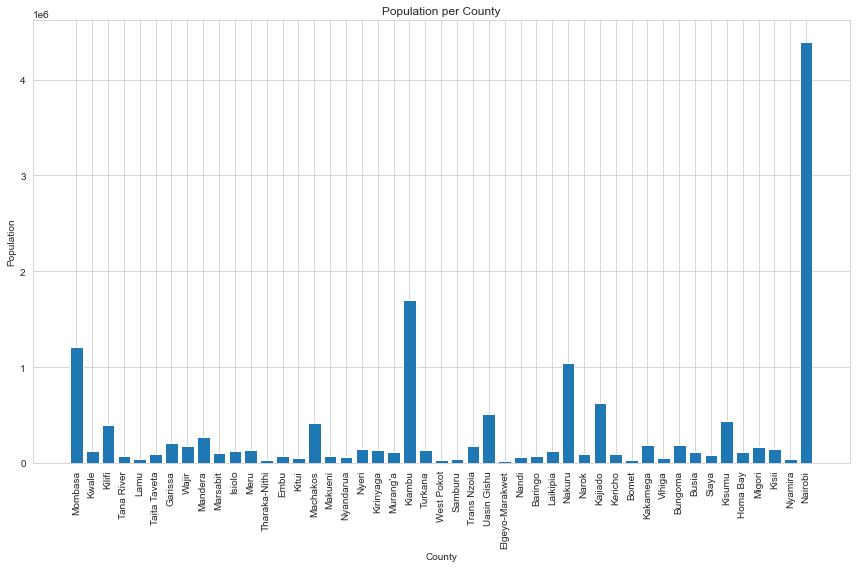

In [75]:
# Create bar chart of population by county
plt.figure()
plt.bar(county_df['county'], county_df['population'])
plt.xticks(rotation=90)
plt.title("Population per County")
plt.xlabel("County")
plt.ylabel("Population")
plt.tight_layout()
plt.show()


***Population vs Number of Stations***

Scatter plot to examine the relationship between population and existing charging infrastructure.

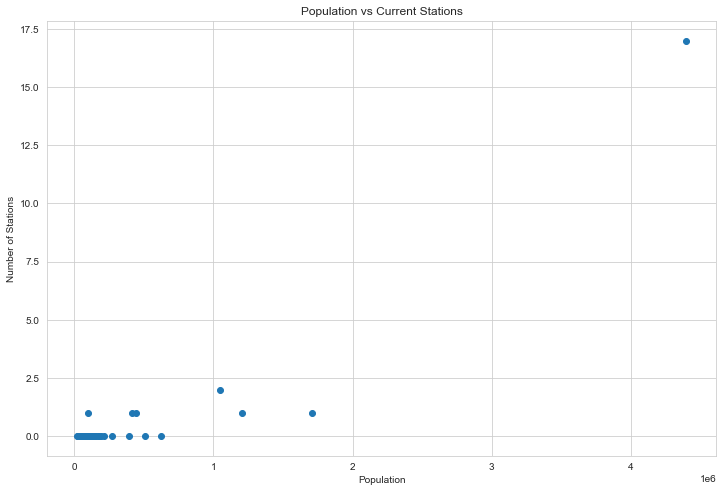

In [76]:
# Scatter plot of population vs number of stations
plt.figure()
plt.scatter(county_df["population"], county_df["num_stations"])
plt.xlabel("Population")
plt.ylabel("Number of Stations")
plt.title("Population vs Current Stations")
plt.show()

***Correlation Matrix***

Heatmap showing correlations between numerical features to understand relationships in the data.

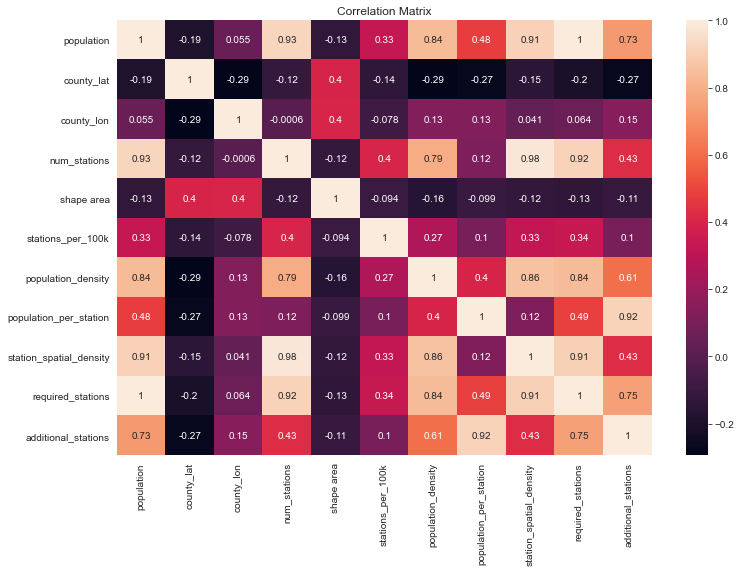

In [77]:
# Select only numeric columns
numeric_df = county_df.select_dtypes(include=[np.number])

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

***Counties with Infrastructure Gap***

Horizontal bar chart highlighting counties with the greatest need for additional charging stations.

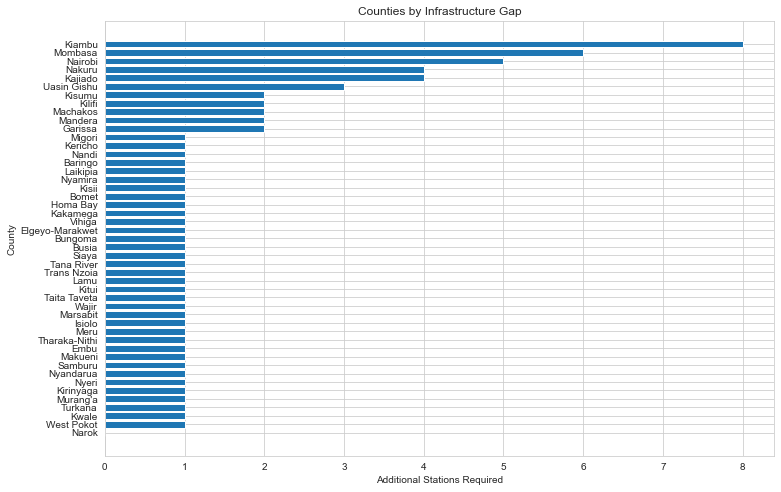

In [78]:
# Sort counties by additional stations needed (descending)
gap = county_df.sort_values("additional_stations", ascending=False)

plt.figure()
plt.barh(gap["county"], gap["additional_stations"])
plt.xlabel("Additional Stations Required")
plt.ylabel("County")
plt.title("Counties by Infrastructure Gap")
plt.gca().invert_yaxis()   # Highest gap at top
plt.show()

## **Modeling**

### **Additional Stations Model**

In [79]:

# Predictive modeling to estimate additional stations based on demographic features


# Prepare features (excluding target and non-predictive columns)
feature_cols = ['population', 'population_density', 'num_stations', 
                'station_spatial_density','shape area']
target_col = 'additional_stations'

# Handle infinite values in population_per_station
X = county_df[feature_cols]
y = county_df[target_col]



In [80]:

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [81]:

rkf = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

scoring = {
    'r2': 'r2',
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error'
}

cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=rkf,
    scoring=scoring,
    return_train_score=False
)

print("Mean CV R²:", np.mean(cv_results['test_r2']))
print("Mean CV RMSE:", -np.mean(cv_results['test_neg_rmse']))
print("Mean CV MAE:", -np.mean(cv_results['test_neg_mae']))

Mean CV R²: 0.6743172218954753
Mean CV RMSE: 0.5523874503313525
Mean CV MAE: 0.2829713629950296


In small structured datasets R^2:

0.5–0.6 = acceptable

0.6–0.75 = strong

0.8 = suspiciously high (possible leakage)

It means MAE:

On average, your model is wrong by only 0.28 stations per county.

That is less than one-third of a station.

In [82]:
rf_model.fit(X, y)
county_df["predicted_additional_stations"] = rf_model.predict(X).round().astype(int)

In [83]:
county_df.head()

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k,population_density,population_per_station,station_spatial_density,required_stations,additional_stations,predicted_additional_stations
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759,6.351624e+07,1208333.0,52.565181,7.0,6.0,6
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000,1.877904e+05,126431.0,0.000000,1.0,1.0,1
2,Kilifi,393888,-3.666670,39.750000,0.0,1.025128,0.000000,3.842330e+05,393888.0,0.000000,2.0,2.0,2
3,Tana River,75722,-1.533330,39.416670,0.0,3.185405,0.000000,2.377155e+04,75722.0,0.000000,1.0,1.0,1
4,Lamu,38446,-2.271690,40.902010,0.0,0.491574,0.000000,7.820999e+04,38446.0,0.000000,1.0,1.0,1


In [84]:
joblib.dump(rf_model, "./ml_models/additional_station_model.joblib")

['./ml_models/additional_station_model.joblib']

### **Station Placement Model**

In [85]:
from sklearn.cluster import KMeans
import numpy as np

def allocate_new_stations(county, kenya_stations, k):

    county_name = county["county"]
    
    county_stations = kenya_stations[
        kenya_stations["county"] == county_name
    ]
    
    existing_coords = county_stations[["latitude","longitude"]].values
    
    # If no additional stations needed
    if k == 0:
        return None, [], None
    
    np.random.seed(42)
    
    # Generate synthetic candidate points across county
    county_lat = county["county_lat"]
    county_lon = county["county_lon"]
    
    synthetic_points = []
    
    for _ in range(max(k*5, 20)):
        synthetic_points.append([
            county_lat + np.random.uniform(-0.063, 0.063),
            county_lon + np.random.uniform(-0.063, 0.063)
        ])
    
    synthetic_points = np.array(synthetic_points)
    
    # Combine existing + synthetic
    if len(existing_coords) > 0:
        training_points = np.vstack([existing_coords, synthetic_points])
    else:
        training_points = synthetic_points
    
    # Run ONE KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(training_points)
    
    return kmeans, kmeans.cluster_centers_, training_points

In [86]:
county_models = {}
county_training_data = {}
all_new_locations = []

for _, county in county_df.iterrows():
    
    k = int(county["predicted_additional_stations"])
    
    kmeans_model, centers, training_points = allocate_new_stations(
        county, kenya_stations, k
    )
    
    county_name = county["county"]
    
    county_models[county_name] = kmeans_model
    county_training_data[county_name] = training_points
    
    for center in centers:
        all_new_locations.append({
            "county": county_name,
            "latitude": center[0],
            "longitude": center[1]
        })

final_df = pd.DataFrame(all_new_locations)

In [87]:
final_df

,county,latitude,longitude
0,Mombasa,-4.040131,39.627321
1,Mombasa,-4.086400,39.665336
2,Mombasa,-4.053727,39.706614
3,Mombasa,-4.112050,39.716960
4,Mombasa,-4.098100,39.624741
...,...,...,...
70,Nairobi,-1.302586,36.818332
71,Nairobi,-1.243945,36.857983
72,Nairobi,-1.332625,36.880326
73,Nairobi,-1.329118,36.774442


### Model evaluation

In [88]:
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import numpy as np

def evaluate_kmeans(kmeans, training_points):
    
    # Handle cases where no KMeans model exists or training points are empty
    if kmeans is None or training_points is None or len(training_points) == 0:
        return {
            "inertia": 0,
            "silhouette_score": None,
            "avg_intra_cluster_distance": 0,
            "avg_inter_cluster_distance": 0
        }
    
    metrics = {}
    
    # Inertia (WCSS)
    metrics["inertia"] = kmeans.inertia_
    
    # Silhouette Score
    # Only valid if more than 1 cluster and enough samples
    if len(set(kmeans.labels_)) > 1 and len(training_points) > len(set(kmeans.labels_)):
        metrics["silhouette_score"] = silhouette_score(training_points, kmeans.labels_)
    else:
        metrics["silhouette_score"] = None
    
    # Average Intra-Cluster Distance
    distances_to_centers = cdist(training_points, kmeans.cluster_centers_)
    closest_distances = np.min(distances_to_centers, axis=1)
    metrics["avg_intra_cluster_distance"] = np.mean(closest_distances)
    
    # Average Inter-Cluster Distance
    center_distances = cdist(kmeans.cluster_centers_, kmeans.cluster_centers_)
    
    # Remove diagonal zeros
    non_zero_distances = center_distances[center_distances != 0]
    
    if len(non_zero_distances) > 0:
        metrics["avg_inter_cluster_distance"] = np.mean(non_zero_distances)
    else:
        metrics["avg_inter_cluster_distance"] = 0
    
    return metrics

In [89]:
county_metrics = []

for county_name, model in county_models.items():
    
    training_points = county_training_data[county_name]
    
    # Ensure training_points is an array
    if training_points is None:
        training_points = np.empty((0, 2))

    metrics = evaluate_kmeans(model, training_points)
    metrics["county"] = county_name
    metrics["num_points"] = len(training_points)
    
    county_metrics.append(metrics)

metrics_df = pd.DataFrame(county_metrics)

In [90]:
summary_metrics = {
    "mean_silhouette": metrics_df["silhouette_score"].mean(),
    "mean_inertia_per_point": (metrics_df["inertia"] / metrics_df["num_points"]).mean(),
    "mean_intra_cluster_distance": metrics_df["avg_intra_cluster_distance"].mean(),
    "mean_inter_cluster_distance": metrics_df["avg_inter_cluster_distance"].mean()
}
summary_metrics

{'mean_silhouette': 0.4679911688522056,
 'mean_inertia_per_point': 0.0023125646664138967,
 'mean_intra_cluster_distance': 0.043861407269995344,
 'mean_inter_cluster_distance': 0.030515022548244775}

In [91]:

# Save the model
joblib.dump(county_models, "./ml_models/county_models.joblib")

['./ml_models/county_models.joblib']

In [92]:
loaded_models = joblib.load("./ml_models/county_models.joblib")

# Example: get Narok model
narok_model = loaded_models["Narok"]
nairobi_model = loaded_models["Nairobi"]
kiambu_model = loaded_models["Kiambu"]
narok_model, nairobi_model, kiambu_model


(KMeans(n_clusters=1, random_state=42),
 KMeans(n_clusters=6, random_state=42),
 KMeans(n_clusters=6, random_state=42))

### Geospatial Visualization

### Existing Charging Stations Map

In [93]:
# Center map roughly around Kenya
kenya_map_existing = folium.Map(location=[0.5, 37], zoom_start=6)

# Add existing stations
for _, station in kenya_stations.iterrows():
    folium.CircleMarker(
        location=[station["latitude"], station["longitude"]],
        radius=5,
        popup=station["station name"],
        fill=True
    ).add_to(kenya_map_existing)


kenya_map_existing

In [94]:
# Create map centered on Kenya
kenya_map_predicted = folium.Map(location=[0.5, 37], zoom_start=6)


# Add predicted stations as blue circle markers
for _, station in final_df.iterrows():
    folium.CircleMarker(
        location=[station["latitude"], station["longitude"]],
        radius=6,
        popup=station["county"],
        fill=True
    ).add_to(kenya_map_predicted)

kenya_map_predicted

In [95]:
# Create map centered on Kenya
kenya_map_combined = folium.Map(location=[0.5, 37], zoom_start=6)

# Add existing stations in green
for _, row in kenya_stations.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        popup=row["station name"],
        color="green",
        fill=True
    ).add_to(kenya_map_combined)

# Add predicted stations in blue
for _, row in final_df.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6,
        popup=row["county"],
        color="blue",
        fill=True
    ).add_to(kenya_map_combined)

kenya_map_combined

In [96]:
kenya_stations.to_csv('./app/utilities/kenya_stations_clean.csv', index=False)
county_df.to_csv('./app/utilities/county_data_clean.csv', index=False)